# Introduction to NLP Fundamentals in TensorFlow

NLP has the goal of deriving information out of natural language (could be sequences of text or speech).

Another common term for NLP problems is sequence to sequence problems (seq2seq).

In [1]:
# ============================================================================
# ⚡ GEEKOM A9 MAX - Setup Rápido para Estudos
# Cole no início de qualquer notebook e execute primeiro
# ============================================================================

import os, warnings
os.environ.update({
    'TF_CPP_MIN_LOG_LEVEL': '2',           # Menos logs
    'TF_ENABLE_ONEDNN_OPTS': '1',          # oneDNN (2-3x mais rápido)
    'OMP_NUM_THREADS': '32',               # 32 threads
    'MKL_NUM_THREADS': '32',
    'TF_NUM_INTEROP_THREADS': '4',
    'TF_NUM_INTRAOP_THREADS': '32',
    'TF_XLA_FLAGS': '--tf_xla_auto_jit=2', # XLA JIT
    'CUDA_VISIBLE_DEVICES': '-1',          # CPU only
})
warnings.filterwarnings('ignore')

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Config TensorFlow
try: 
    tf.config.optimizer.set_jit(True)
    tf.config.threading.set_inter_op_parallelism_threads(4)
    tf.config.threading.set_intra_op_parallelism_threads(32)
except: pass
tf.config.set_visible_devices([], 'GPU')

# Gráficos
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [14, 6]

print(f"✅ TensorFlow {tf.__version__} | Ryzen 9 (32t) | 96GB RAM | oneDNN ativo")
print("="*80)


✅ TensorFlow 2.15.0 | Ryzen 9 (32t) | 96GB RAM | oneDNN ativo


In [2]:
# Import series of helper functions for the notebook
from helper_functions import unzip_data, create_tensorboard_callback, plot_loss_curves, compare_historys

## Get a text dataset

The dataset we're going to be using is Kaggle's introduction to NLP dataset (text samples of Tweets labelled as disaster or not disaster).

In [3]:
# import zipfile
# import urllib.request

# # Baixar o arquivo ZIP
# url = "https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip"
# zip_path = "nlp_getting_started.zip"
# urllib.request.urlretrieve(url, zip_path)

# # # Descompactar o arquivo ZIP
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall()

## Visualization of the data (text)

Once you've acquired a new dataset to work with, what should you do first?

Explore it? Inspect it? Verify it? Become one with it?

All correct.

Remember the motto: visualize, visualize, visualize.

Right now, our text data samples are in the form of '.csv' files. For an easy way to make them visual, let's turn them into pandas DataFrame's.

📖 Reading: You might come across text datasets in many different formats. Aside from CSV files (what we're working with), you'll probably encounter '.txt' files and '.json' files too. In this section, we'll learn how to read these types of files as well. For working with these type of files, I'd recommend reading the two following articles by RealPython:

* [How to Read and Write Files in Python](https://realpython.com/read-write-files-python/)
* [How to Read and Write JSON Files in Python](https://realpython.com/python-json/)

In [4]:
import pandas as pd
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print(train_df.head())

   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


In [5]:
# Shuffle training dataframe
train_df_shuffled = train_df.sample(frac=1, random_state=42) # random_state is set to 42 for reproducibility
train_df_shuffled.head()

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0


In [6]:
# What does the test dataframe look like?
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [7]:
# How many examples of each class are in the training set?
train_df.target.value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

In [8]:
# How many total samples?
len(train_df), len(test_df)

(7613, 3263)

In [9]:
# Let's visualize some random training examples
import random
random_index = random.randint(0, len(train_df)-5)
for row in train_df_shuffled[["text", "target"]][random_index:random_index+5].itertuples():
    _, text, target = row
    print(f"Target: {target}", "(real threat)" if target > 0 else "(not a threat)")
    print(f"Text:\n{text}\n")
    print("---\n")

Target: 1 (real threat)
Text:
Enugu Government to demolish illegal structures at International Conference Centre http://t.co/ouYLwuIXcs

---

Target: 1 (real threat)
Text:
@weathernetwork here comes the hail!

---

Target: 0 (not a threat)
Text:
@JimMozel puck=flattened ball lol

---

Target: 0 (not a threat)
Text:
@nashhmu have a meltdown he noticed you

---

Target: 1 (real threat)
Text:
@Stretcher @witter @Rexyy @Towel show me a picture of it

---



### Split data into training and valiation sets

In [10]:
# split the data into training and testing sets
from sklearn.model_selection import train_test_split

In [11]:
# Use train_test_split to split the data into training and testing sets.
train_sentences, val_sentences, train_labels, val_labels = train_test_split(train_df_shuffled["text"].to_numpy(),
                                                                            train_df_shuffled["target"].to_numpy(),
                                                                            test_size=0.1,  # 10% of the data
                                                                            random_state=42) # random seed for reproducibility

In [12]:
# Check the length of the text.
len(train_sentences), len(train_labels), len(val_sentences), len(val_labels)

(6851, 6851, 762, 762)

In [13]:
# Check  the first 10 samples
train_sentences[:10], train_labels[:10]

(array(['@mogacola @zamtriossu i screamed after hitting tweet',
        'Imagine getting flattened by Kurt Zouma',
        '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
        "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
        'Somehow find you and I collide http://t.co/Ee8RpOahPk',
        '@EvaHanderek @MarleyKnysh great times until the bus driver held us hostage in the mall parking lot lmfao',
        'destroy the free fandom honestly',
        'Weapons stolen from National Guard Armory in New Albany still missing #Gunsense http://t.co/lKNU8902JE',
        '@wfaaweather Pete when will the heat wave pass? Is it really going to be mid month? Frisco Boy Scouts have a canoe trip in Okla.',
        'Patient-reported outcomes in long-term survivors of metastatic colorectal cancer - British Journal of Surgery http://t.co/5Yl4DC1Tqt'],
       dtype=object),
 array([0,

## Converting text into numbers

When dealing with a text problem, one of the first things you'll have to do before you can build a model is to convert your text to numbers.
There are a few ways to do this, namely:
- Tokenization – direct mapping of a token (a token could be a word or a character) to a number
- Embedding – create a matrix of feature vectors for each token (the size of the feature vector can be defined and this embedding can be learned)

In [14]:
# convert text to numbers.
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization

text_vectorizer = TextVectorization(max_tokens=10000, # how many words in the vocabulary (automatically add <OOV>)
                                    standardize="lower_and_strip_punctuation", # convert text to lowercase and remove punctuation
                                    split="whitespace", # split text into words or characters
                                    ngrams=None, # create groups of words or characters
                                    output_mode="int", # how to convert tokens to numbers
                                    output_sequence_length=None, # how long is the output sequence
                                    pad_to_max_tokens=True) # pad the sequence to the max length 

In [15]:
len(train_sentences[0].split()) # how many words in the first tweet

7

In [16]:
# Finde the average numbers of tokens (words) in the training tweets

round(sum([len(tweet.split()) for tweet in train_sentences])/len(train_sentences))

15

In [17]:
# Setup text Vectorization variables
max_vocab_length = 10000 # how many unique words in the vocabulary
max_length = 15 # max length of a text to consider

text_vectorizer = TextVectorization(max_tokens=max_vocab_length,
                                    output_mode="int",
                                    output_sequence_length=max_length)

In [18]:
# Fit the text vectorizer on the training tweets
text_vectorizer.adapt(train_sentences)


In [19]:
# Create a sample sentence and tokenize it
sample_sentence = " There's a flood in my street!"
text_vectorizer([sample_sentence])

<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[264,   3, 232,   4,  13, 698,   0,   0,   0,   0,   0,   0,   0,
          0,   0]], dtype=int64)>

In [20]:
# Choose a random sentence from the training dataset and tokenize it
random_sentence = random.choice(train_sentences)   
print(f"Original tweet: \n {random_sentence}\
      \n\nVectorized Version:")
text_vectorizer([random_sentence])

Original tweet: 
 #NowPlaying 'The Lightning Strike' de Snow Patrol de A Hundred Million Suns ? http://t.co/GrzcHkDF37      

Vectorized Version:


<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[ 619,    2,  300, 1251, 1217, 1363, 9911, 1217,    3, 3761, 1272,
        7930,    1,    0,    0]], dtype=int64)>

In [21]:
# get the unique words in the vocabulary
words_in_vocab = text_vectorizer.get_vocabulary() # get all the unique words in the vocabulary
top_5_words = words_in_vocab[:5] # get the top 5 words in the vocabulary
bottom_5_words = words_in_vocab[-5:] # get the bottom 5 words in the vocabulary
print(f"Numbers of words in vocab: {len(words_in_vocab)}")
print(f"5 most commom words: {top_5_words}")
print(f"5 least commom words: {bottom_5_words}")

Numbers of words in vocab: 10000
5 most commom words: ['', '[UNK]', 'the', 'a', 'in']
5 least commom words: ['pages', 'paeds', 'pads', 'padres', 'paddytomlinson1']


### Creating and Embedding using Embedding Layer

Creating an Embedding using an Embedding Layer
We've got a way to map our text to numbers. How about we go a step further and turn those numbers into an embedding?

The powerful thing about an embedding is it can be learned during training. This means rather than just being static (e.g. 1 = I, 2 = love, 3 = TensorFlow), a word's numeric representation can be improved as a model goes through data samples.

We can see what an embedding of a word looks like by using the [tf.keras.layers.Embedding laye](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding)r.

The main parameters we're concerned about here are:

* `input_dim` - The size of the vocabulary (e.g. len(text_vectorizer.get_vocabulary()).
* `output_dim` - The size of the output embedding vector, for example, a value of 100 outputs a feature vector of size 100 for each word.
* `embeddings_initializer` - How to initialize the embeddings matrix, default is "uniform" which randomly initalizes embedding matrix with uniform distribution. This can be changed for using pre-learned embeddings.
* `input_length` - Length of sequences being passed to embedding layer.
  
Knowing these, let's make an embedding layer.

In [22]:
from tensorflow.keras import layers

embedding = layers.Embedding(input_dim=max_vocab_length,
                            output_dim=128,
                            input_length=max_length,
                            )

In [23]:
# get a random sentence from the training set
random_sentence = random.choice(train_sentences)
print(f"Original tweet: \n {random_sentence}\
            \n\nEmbedded Version:")

# Embed the radon sentence (turn it into a dense vector of fixed sizes)
sample_embed = embedding(text_vectorizer([random_sentence]))
sample_embed 

Original tweet: 
 Emergency Shutdown Systems - Edmonton http://t.co/F8GvWkFqox            

Embedded Version:


<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[ 0.02417492, -0.00928239, -0.04434704, ...,  0.02738375,
         -0.02661465,  0.00611196],
        [-0.00306246, -0.02599706,  0.02975719, ...,  0.02554493,
         -0.04038321,  0.04392881],
        [ 0.01699303, -0.00230938, -0.03072047, ..., -0.00971754,
         -0.03854965, -0.03834264],
        ...,
        [ 0.03367927, -0.03628852, -0.0084049 , ..., -0.00197127,
          0.0190491 ,  0.03121248],
        [ 0.03367927, -0.03628852, -0.0084049 , ..., -0.00197127,
          0.0190491 ,  0.03121248],
        [ 0.03367927, -0.03628852, -0.0084049 , ..., -0.00197127,
          0.0190491 ,  0.03121248]]], dtype=float32)>

In [24]:
# Check out a single token's embedding
sample_embed[0][0], sample_embed[0][0].shape, random_sentence

(<tf.Tensor: shape=(128,), dtype=float32, numpy=
 array([ 0.02417492, -0.00928239, -0.04434704,  0.01067153,  0.01825423,
        -0.0365122 ,  0.04483484,  0.03107251, -0.0476913 , -0.03593695,
        -0.01509599,  0.04397415, -0.01475323,  0.00636426,  0.03654123,
        -0.03208389,  0.02419083, -0.00492687,  0.0384316 , -0.04481868,
        -0.01354444,  0.03392254,  0.0159932 ,  0.01261706, -0.02763938,
         0.01139952,  0.00157396,  0.01626733, -0.02892348, -0.0005762 ,
        -0.04155655, -0.04622822, -0.00481645,  0.01259192, -0.01630727,
         0.03305823, -0.01278161,  0.01247046, -0.04926236, -0.01878828,
        -0.03761999,  0.04005415,  0.04451536, -0.03793697, -0.03353356,
        -0.0065136 ,  0.03128469,  0.03897298,  0.02759821, -0.02327471,
        -0.0206926 , -0.01644623,  0.03522327,  0.00920624, -0.03877842,
         0.03316731, -0.00120457, -0.04632969,  0.02478922,  0.02974841,
         0.02989526, -0.04170165,  0.00964856, -0.02915704,  0.00191305,
  

### Modelling a text dataset (running a series of experiments)
Now we've got a way to turn our text sequences into numbers, it's time to start building a series of modelling experiments.
We'll start with a baseline and move on from there.
- Model 0: Naive Bayes (baseline), this is from Sklearn ML map: https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html (scikit-learn.org in Bing)
- Model 1: Feed-forward neural network (dense model)
- Model 2: LSTM model (RNN)
- Model 3: GRU model (RNN)
- Model 4: Bidirectional-LSTM model (RNN)
- Model 5: 1D Convolutional Neural Network (CNN)
- Model 6: TensorFlow Hub Pretrained Feature Extractor (using transfer learning for NLP)
- Model 7: Same as model 6 with 10% of training data


How are we going to approach all of these?
Use the standard steps in modelling with TensorFlow:
- Create a model
- Build a model
- Fit a model
- Evaluate our model


### Model 0: Getting a baseline

As with all machine learning modelling experiments, it's important to create a baseline model so you've got a benchmark for future experiments to build upon.
To create our baseline, we'll use Sklearn's Multinomial Naive Bayes using the TF‑IDF formula to convert our words to numbers.
> 🔑 Note: It's common practice to use non‑DL algorithms as a baseline because of their speed and then later use DL to see if you can improve upon them.



In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
# Create the pipeline

model_0 = Pipeline([
    ('tfidf', TfidfVectorizer()), # convert text to numbers
    ('clf', MultinomialNB()) # model the text
])

# Fit the pipeline to the training data
model_0.fit(train_sentences, train_labels)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [26]:
# Evaluate our baseline model
baseline_score = model_0.score(train_sentences, train_labels)
print(f"Our baseline model achieves an accuracy of: {baseline_score:.3f}%")

Our baseline model achieves an accuracy of: 0.887%


In [27]:
# Make predictions
baseline_preds = model_0.predict(val_sentences)
baseline_preds[:20]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
      dtype=int64)

### Creating an evaluation function for our model experiments
We could evaluate these as they are but since we're going to be evaluating several models in the same way going forward, let's create a helper function which takes an array of predictions and ground truth labels and computes the following:

* Accuracy
* Precision
* Recall
* F1-score
> 🔑 Note: Since we're dealing with a classification problem, the above metrics are the most appropriate. If we were working with a regression problem, other metrics such as MAE (mean absolute error) would be a better choice. We can find more at: https://scikit-learn.org/0.16/modules/model_evaluation.html

In [28]:
# Function to evaluate: accuracy, precision, recall, f1-score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def calculate_results(y_true, y_pred):
  """
  Calculates model accuracy, precision, recall and f1 score of a binary classification model.

  Args:
  -----
  y_true = true labels in the form of a 1D array
  y_pred = predicted labels in the form of a 1D array

  Returns a dictionary of accuracy, precision, recall, f1-score.
  """
  # Calculate model accuracy
  model_accuracy = accuracy_score(y_true, y_pred) * 100
  # Calculate model precision, recall and f1 score using "weighted" average
  model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
  model_results = {"accuracy": model_accuracy,
                  "precision": model_precision,
                  "recall": model_recall,
                  "f1": model_f1}
  return model_results

In [29]:
# get baseline results
baseline_results = calculate_results(y_true=val_labels, y_pred=baseline_preds)
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

### Model 1: Simple dense model

In [30]:
# Create a tensorboard callback (need to create a new one for each model)
from helper_functions import create_tensorboard_callback

# create a directory to save TensorBoard logs
SAVE_DIR = "model_logs"

In [31]:
from tensorflow.keras import layers

inputs = layers.Input(shape=(1,), dtype="string")
x = text_vectorizer(inputs)       # (None, 1) → (None, sequence_length)
x = embedding(x)                  # (None, sequence_length) → (None, sequence_length, embed_dim)
x = layers.GlobalAveragePooling1D()(x)  # (None, sequence_length, embed_dim) → (None, embed_dim)
outputs = layers.Dense(1, activation="sigmoid")(x)  # (None, embed_dim) → (None, 1)

model_1 = tf.keras.Model(inputs, outputs, name="model_1_dense")

In [32]:
model_1.summary()

Model: "model_1_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 1280129 (4.88 MB)
Trainable params: 128

In [33]:
# Compile the model
model_1.compile(
    loss="binary_crossentropy",  # NOT sparse_categorical or from_logits=True
    optimizer="adam",
    metrics=["accuracy"]
)

In [34]:
model_1.summary()

Model: "model_1_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 1280129 (4.88 MB)
Trainable params: 128

In [35]:
# Check intermediate shapes
print("After vectorizer:", text_vectorizer(tf.constant(["test"])).shape)
print("Model summary:")
model_1.summary()

After vectorizer: (1, 15)
Model summary:
Model: "model_1_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params

In [36]:
# Fit the model
model_1_history = model_1.fit(x=train_sentences, # input sentences can be a list of strings due to text preprocessing layer built-in model
                              y=train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels),
                              callbacks=[create_tensorboard_callback(dir_name=SAVE_DIR, 
                                                                     experiment_name="simple_dense_model")])

Saving TensorBoard log files to: model_logs/simple_dense_model/20260417-192157
Epoch 1/5

215/215 [==============================] - 1s 5ms/step - loss: 0.6128 - accuracy: 0.6907 - val_loss: 0.5377 - val_accuracy: 0.7520
Epoch 2/5
215/215 [==============================] - 1s 5ms/step - loss: 0.4433 - accuracy: 0.8199 - val_loss: 0.4745 - val_accuracy: 0.7874
Epoch 3/5
215/215 [==============================] - 1s 5ms/step - loss: 0.3480 - accuracy: 0.8571 - val_loss: 0.4572 - val_accuracy: 0.7861
Epoch 4/5
215/215 [==============================] - 1s 5ms/step - loss: 0.2850 - accuracy: 0.8911 - val_loss: 0.4622 - val_accuracy: 0.7861
Epoch 5/5
215/215 [==============================] - 1s 5ms/step - loss: 0.2379 - accuracy: 0.9110 - val_loss: 0.4779 - val_accuracy: 0.7861


In [37]:
# Check the results
model_1.evaluate(val_sentences, val_labels)

24/24 [==============================] - 0s 1ms/step - loss: 0.4779 - accuracy: 0.7861


[0.4779140055179596, 0.7860892415046692]

In [38]:
embedding.weights

[<tf.Variable 'embedding/embeddings:0' shape=(10000, 128) dtype=float32, numpy=
 array([[ 0.04483432, -0.04644193, -0.02059704, ..., -0.01321269,
          0.00922411,  0.02722172],
        [ 0.02952149, -0.0528434 , -0.00510875, ...,  0.03756414,
         -0.04682318,  0.02154939],
        [ 0.03678294,  0.01061025,  0.02271499, ..., -0.01908303,
          0.018194  , -0.0483418 ],
        ...,
        [ 0.00475451,  0.03909186, -0.0154029 , ...,  0.03742803,
          0.046473  ,  0.020655  ],
        [ 0.03866031, -0.08240141, -0.03491638, ..., -0.0236515 ,
         -0.05925477, -0.09222554],
        [ 0.06576739, -0.02880801, -0.02027508, ..., -0.10851739,
         -0.11146263, -0.0357345 ]], dtype=float32)>]

In [39]:
# Make some predictions with our new model and evaluate those predictions
model_1_pred_probs = model_1.predict(val_sentences)
model_1_pred_probs.shape

24/24 [==============================] - 0s 1ms/step


(762, 1)

In [40]:
model_1_pred_probs[0]

array([0.3544103], dtype=float32)

In [41]:
model_1_pred_probs[:10]

array([[0.3544103 ],
       [0.82096976],
       [0.99705535],
       [0.1251763 ],
       [0.1177107 ],
       [0.93469626],
       [0.90386206],
       [0.9924747 ],
       [0.95213264],
       [0.29734203]], dtype=float32)

In [42]:
# Convert prediction probabilities to labels
model_1_preds = tf.round(model_1_pred_probs)  # rounds 0.5+ to 1, below 0.5 to 0
model_1_preds.shape  # (762, 1) — still fine

# Flatten if needed for evaluation
model_1_preds = tf.squeeze(model_1_preds)  # (762,) — matches val_labels shape
model_1_preds.shape  # (762,)

TensorShape([762])

In [43]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, model_1_preds))

              precision    recall  f1-score   support

           0       0.77      0.87      0.82       414
           1       0.82      0.68      0.74       348

    accuracy                           0.79       762
   macro avg       0.79      0.78      0.78       762
weighted avg       0.79      0.79      0.78       762



In [44]:
# Convert model prediction probabilities to label format
model_1_preds = tf.squeeze(tf.round(model_1_pred_probs))
model_1_preds[:20]

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1.], dtype=float32)>

In [45]:
# Calculate our model_1 results
from pyexpat import model


model_1_results = calculate_results(y_true=val_labels, y_pred=model_1_preds)
print(model_1_results)

{'accuracy': 78.60892388451444, 'precision': 0.7899352475221245, 'recall': 0.7860892388451444, 'f1': 0.7834372696728736}


In [46]:
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

In [47]:
import numpy as np
np.array(list(model_1_results.values()) > np.array(list(baseline_results.values())))


array([False, False, False, False])

## Visualize learned embeddings

In [48]:
# get the vocabulary from the text vectorization
words_in_vocab = text_vectorizer.get_vocabulary()
len(words_in_vocab), words_in_vocab[:20]

(10000,
 ['',
  '[UNK]',
  'the',
  'a',
  'in',
  'to',
  'of',
  'and',
  'i',
  'is',
  'for',
  'on',
  'you',
  'my',
  'with',
  'it',
  'that',
  'at',
  'by',
  'this'])

In [49]:
# Model1 summary
model_1.summary()

Model: "model_1_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 1280129 (4.88 MB)
Trainable params: 128

In [50]:
# Get the weight matrix of embedding layer
# (these are the numerical representations of each token in our training data, wich have been learned for 5 epochs)
embed_weights = model_1.get_layer('embedding').get_weights()[0]
print(embed_weights.shape) # same size as vocab size and embedding dim (output dim of our embedding layer)

(10000, 128)


Now we've got the embedding matrix our model has learned to represent our tokens, let's see how we can visualize it.

To do so, TensorFlow has a handy tool called projector: http://projector.tensorflow.org/

And TensorFlow also has an incredible guide on word embeddings themselves: https://www.tensorflow.org/text/tutorials/word_embeddings

In [51]:
# Create embedding files (we got this from TensorFlo's word embedding documentation )

import io
out_v = io.open('vectors.tsv', 'w', encoding='utf-8') # write vectors.tsv
out_m = io.open('metadata.tsv', 'w', encoding='utf-8') # write metadata.tsv

for index, word in enumerate(words_in_vocab):
  if index == 0:
    continue  # skip 0, it's padding.
  vec = embed_weights[index]
  out_v.write('\t'.join([str(x) for x in vec]) + "\n")
  out_m.write(word + "\n")
out_v.close()
out_m.close()


## Recurrent Neural Networks (RNN's)

Recurrent Neural Networks (RNN's)

RNN's are useful for sequence data.

The premise of a recurrent neural network is to use the representation of a previous input to aid the representation of a later input.

If you want an overview of the internals of a recurrent neural network, see the following:
- MIT's sequence modelling lecture https://youtu.be/qjrad0V0uJE
- Chris Olah's intro to LSTMs: https://colah.github.io/posts/2015-08-Understanding-LSTMs/
- Andrej Karpathy's the unreasonable effectiveness of recurrent neural networks: http://karpathy.github.io/2015/05/21/rnn-effectiveness/

### Model 2: LSTM

LSTM = long short term memory (one of the most popular LSTM cells)

Our structure of an RNN typically looks like this:

```
Input (text) -> Tokenize -> Embedding -> Layers (RNNs/dense) -> Output (label probability)
```

In [52]:
# Create an LSTM model
from tensorflow.keras import layers
inputs = layers.Input(shape=(1,), dtype='string')
x = text_vectorizer(inputs)
x = embedding(x)
# print(x.shape)
# x = layers.LSTM(64, return_sequences=True)(x) # when you're stacking RNN cells together, you will need to return_sequences=True 
# print(x.shape)
x = layers.LSTM(64)(x)
# print(x.shape)
# x = layers.Dense(64, activation='relu')(x)
# print(x.shape)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_2 = tf.keras.Model(inputs, outputs, name='model_2_LSTM')

In [53]:
# get a summary of the model
model_2.summary()

Model: "model_2_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1329473 (5.07 MB)
Trainable params: 1329473 (5.07 MB)
Non-trainable params: 0 (0.00 Byte)
________________

In [54]:
# Compile the model
model_2.compile(loss='binary_crossentropy', 
                optimizer='adam', 
                metrics=['accuracy'])

In [55]:
# Fit the model
model_2_history = model_2.fit(train_sentences,
                                train_labels, 
                                epochs=5, 
                                validation_data=(val_sentences, val_labels),
                                callbacks=[create_tensorboard_callback(SAVE_DIR,
                                                                    'model_2_LSTM')])

Saving TensorBoard log files to: model_logs/model_2_LSTM/20260417-192204
Epoch 1/5
215/215 [==============================] - 3s 9ms/step - loss: 0.2213 - accuracy: 0.9190 - val_loss: 0.5441 - val_accuracy: 0.7874
Epoch 2/5
215/215 [==============================] - 2s 9ms/step - loss: 0.1557 - accuracy: 0.9429 - val_loss: 0.6419 - val_accuracy: 0.7822
Epoch 3/5
215/215 [==============================] - 2s 9ms/step - loss: 0.1253 - accuracy: 0.9537 - val_loss: 0.7183 - val_accuracy: 0.7874
Epoch 4/5
215/215 [==============================] - 2s 9ms/step - loss: 0.1036 - accuracy: 0.9628 - val_loss: 0.6991 - val_accuracy: 0.7703
Epoch 5/5
215/215 [==============================] - 2s 8ms/step - loss: 0.0856 - accuracy: 0.9666 - val_loss: 1.1072 - val_accuracy: 0.7703


In [56]:
# make predictions with LSTM model
model_2_pred_probs = model_2.predict(val_sentences)
model_2_pred_probs[:10]

24/24 [==============================] - 0s 2ms/step


array([[7.3090345e-03],
       [7.6978016e-01],
       [9.9986255e-01],
       [8.7964050e-03],
       [2.1942050e-04],
       [9.9973261e-01],
       [2.6643917e-01],
       [9.9990016e-01],
       [9.9983251e-01],
       [5.4479176e-01]], dtype=float32)

In [57]:
# Convert model 2 pred probs to labels
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))
model_2_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 0., 1., 1., 1.], dtype=float32)>

In [58]:
# Calculate model 2 results
model_2_results = calculate_results(y_true=val_labels, 
                                    y_pred=model_2_preds)
model_2_results

{'accuracy': 77.03412073490814,
 'precision': 0.7709806133638261,
 'recall': 0.7703412073490814,
 'f1': 0.7688058109983439}

### Model 3: GRU
Another popular and effective RNN component is the GRU, or gated recurrent unit. The GRU cell has similar features to an LSTM cell but has fewer parameters.


In [59]:
# Build an RNN using the GRU cell
from tensorflow.keras import layers
inputs = layers.Input(shape=(1, ), dtype=tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
# x = layers.GRU(64, return_sequences=True)(x) # if you want to stack recurrent layers on top of each other, you need to set return_sequences=True
# x = layers.LSTM(64, return_sequences=True)(x)
x = layers.GRU(64)(x)
# x = layers.Dense(64, activation="relu")(x)
# x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_3 = tf.keras.Model(inputs, outputs, name="model_3_GRU")

In [60]:
model_3.summary()

Model: "model_3_GRU"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 gru (GRU)                   (None, 64)                37248     
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1317313 (5.03 MB)
Trainable params: 1317313 (5.03 MB)
Non-trainable params: 0 (0.00 Byte)
_________________

In [61]:
# Compile the model
model_3.compile(loss="binary_crossentropy", 
                optimizer="adam", 
                metrics=["accuracy"])

In [62]:
# Fit the model
model_3_history = model_3.fit(train_sentences, 
                              train_labels, 
                              epochs=5, 
                              validation_data=(val_sentences, val_labels), 
                              callbacks=[create_tensorboard_callback(SAVE_DIR, 
                                                                     "model_3_GRU")])


Saving TensorBoard log files to: model_logs/model_3_GRU/20260417-192215
Epoch 1/5
215/215 [==============================] - 3s 9ms/step - loss: 0.1570 - accuracy: 0.9407 - val_loss: 0.7929 - val_accuracy: 0.7756
Epoch 2/5
215/215 [==============================] - 2s 8ms/step - loss: 0.0845 - accuracy: 0.9695 - val_loss: 0.7884 - val_accuracy: 0.7743
Epoch 3/5
215/215 [==============================] - 2s 8ms/step - loss: 0.0716 - accuracy: 0.9723 - val_loss: 0.8790 - val_accuracy: 0.7677
Epoch 4/5
215/215 [==============================] - 2s 7ms/step - loss: 0.0633 - accuracy: 0.9739 - val_loss: 1.0476 - val_accuracy: 0.7730
Epoch 5/5
215/215 [==============================] - 2s 7ms/step - loss: 0.0551 - accuracy: 0.9764 - val_loss: 1.0717 - val_accuracy: 0.7730


In [63]:
# make some predicitions with our GRU model
model_3_pred_probs = model_3.predict(val_sentences)
model_1_preds[:10]

24/24 [==============================] - 0s 2ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

In [64]:
# Convert model 3 pred probs to labels
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))
model_3_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 0., 1., 1., 1.], dtype=float32)>

In [65]:
# Calculate model 3 results
model_3_results = calculate_results(y_true=val_labels, y_pred=model_3_preds)
model_3_results

{'accuracy': 77.29658792650919,
 'precision': 0.7745161732477092,
 'recall': 0.7729658792650919,
 'f1': 0.7709704727215051}

### Model 4: Bidirectional RNN
Normal RNNs go from left to right (just like you'd read an English sentence). However, a bidirectional RNN goes from right to left as well as left to right.


In [66]:
# Build a bidirectional RNN in TensorFlow
from tensorflow.keras import layers
inputs = layers.Input(shape=(1,), dtype="string")
x = text_vectorizer(inputs)
x = embedding(x)
#x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_4 = tf.keras.Model(inputs, outputs, name="model_4_bidirectional")

In [67]:
model_4.summary()

Model: "model_4_bidirectional"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 1378945 (5.26 MB)
Trainable par

In [68]:
# Compile model
model_4.compile(loss="binary_crossentropy", 
                optimizer=tf.keras.optimizers.Adam(), 
                metrics=["accuracy"])

In [69]:
# Fit the model
model_4_history = model_4.fit(train_sentences,
                              train_labels,
                              validation_data=(val_sentences, val_labels),
                              epochs=5,
                              callbacks=[create_tensorboard_callback("SAVE_DIR", "model_4_bidirectional")])

Saving TensorBoard log files to: SAVE_DIR/model_4_bidirectional/20260417-192225
Epoch 1/5
215/215 [==============================] - 4s 11ms/step - loss: 0.1053 - accuracy: 0.9676 - val_loss: 0.9440 - val_accuracy: 0.7690
Epoch 2/5
215/215 [==============================] - 2s 8ms/step - loss: 0.0547 - accuracy: 0.9778 - val_loss: 0.9768 - val_accuracy: 0.7638
Epoch 3/5
215/215 [==============================] - 2s 8ms/step - loss: 0.0459 - accuracy: 0.9788 - val_loss: 1.3034 - val_accuracy: 0.7664
Epoch 4/5
215/215 [==============================] - 2s 9ms/step - loss: 0.0450 - accuracy: 0.9785 - val_loss: 1.3128 - val_accuracy: 0.7690
Epoch 5/5
215/215 [==============================] - 2s 8ms/step - loss: 0.0413 - accuracy: 0.9806 - val_loss: 1.5210 - val_accuracy: 0.7677


In [70]:
# make predictions with our bidirectional model
model_4_pred_probs = model_4.predict(val_sentences)
model_4_pred_probs[:10]

24/24 [==============================] - 0s 2ms/step


array([[6.8796226e-03],
       [6.7485118e-01],
       [9.9997002e-01],
       [2.4989632e-01],
       [1.3123166e-05],
       [9.9988294e-01],
       [6.7918730e-01],
       [9.9998683e-01],
       [9.9996471e-01],
       [9.9734694e-01]], dtype=float32)

In [71]:
# Convert pred probs to pred labels
model_4_preds = tf.squeeze(tf.round(model_4_pred_probs))
model_4_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [72]:
# Calculate the results of our bidirectional model
model_4_results = calculate_results(y_true=val_labels, y_pred=model_4_preds)
model_4_results

{'accuracy': 76.77165354330708,
 'precision': 0.768489862704666,
 'recall': 0.7677165354330708,
 'f1': 0.7660466459325422}

### Convolution Neural Networks for Text (and other types of sequences)
We've used CNNs for images but images are typically 2D (height × width)… however, our text data is 1D.
Previously we've used Conv2D for our image data but now we're going to use Conv1D.
The typical structure of a Conv1D model for sequences (in our case, text):

```
Inputs (text) → Tokenization → Embedding → Layer(s) (typically Conv1D + pooling) → Outputs (class probabilities)
```

### Model 5: Conv1D

- For different exmplanations of parameters see:
https://poloclub.github.io/cnn-explainer/ (for 2D but can relate to 1D)
- Difference between "same" and "valid" padding:
https://stackoverflow.com/questions/37674306/what-is-the-difference-between-same-and-valid-padding-in-tf-nn-max-pool-of-t 

In [73]:
# test out our embedding layer, Conv1D layer and max_pooling layer
embedding_test = embedding(text_vectorizer(["Hello world"])) # turn target sequence into embedding
conv_1D = layers.Conv1D(filters=64, # 
                        kernel_size=5, # kernel_size is the size of the convolutional window (5 words at a time)
                        strides=1,
                        activation="relu",
                        padding="same") # padding="valid" means that the output will be smaller than the input, "same" is the same of the input between layers
conv_1D_output = conv_1D(embedding_test) # apply the convolutional layer to the embedding layer output
max_pool = layers.GlobalMaxPool1D() # max_pooling layer
max_pool_output = max_pool(conv_1D_output) # apply the max_pooling layer to the convolutional layer output the most important features from the sequence.


embedding_test.shape, conv_1D_output.shape, max_pool_output.shape

(TensorShape([1, 15, 128]), TensorShape([1, 15, 64]), TensorShape([1, 64]))

In [74]:
# embedding_test



In [75]:
# conv_1D_output

In [76]:
# max_pool_output

In [77]:
# Create 1-dimensional convolutional layer to model sequences
from tensorflow.keras import layers
inputs = layers.Input(shape=(1,), dtype= tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = layers.Conv1D(filters=64, kernel_size=5, strides=1, activation='relu', padding="valid")(x)
x = layers.GlobalMaxPool1D()(x)
# x = layers.Dense(64, activation='relu')
outputs = layers.Dense(1, activation='sigmoid')(x)
model_5 = tf.keras.Model(inputs, outputs, name="model_5_Conv1D")

# Compile Conv1D
model_5.compile(loss='binary_crossentropy', 
                optimizer='adam', 
                metrics=['accuracy'])

#Get a summary of our model
model_5.summary()


Model: "model_5_Conv1D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 conv1d_1 (Conv1D)           (None, 11, 64)            41024     
                                                                 
 global_max_pooling1d_1 (Gl  (None, 64)                0         
 obalMaxPooling1D)                                               
                                                                 
 dense_4 (Dense)             (None, 1)              

In [78]:
# Fit the model
from gc import callbacks


model_5_history = model_5.fit(train_sentences, 
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels),
                              callbacks=[create_tensorboard_callback(SAVE_DIR, "Conv1D")])

Saving TensorBoard log files to: model_logs/Conv1D/20260417-192237
Epoch 1/5
215/215 [==============================] - 2s 5ms/step - loss: 0.1214 - accuracy: 0.9609 - val_loss: 0.9304 - val_accuracy: 0.7612
Epoch 2/5
215/215 [==============================] - 1s 5ms/step - loss: 0.0731 - accuracy: 0.9730 - val_loss: 1.0384 - val_accuracy: 0.7559
Epoch 3/5
215/215 [==============================] - 1s 5ms/step - loss: 0.0607 - accuracy: 0.9759 - val_loss: 1.1633 - val_accuracy: 0.7559
Epoch 4/5
215/215 [==============================] - 1s 5ms/step - loss: 0.0567 - accuracy: 0.9796 - val_loss: 1.1712 - val_accuracy: 0.7598
Epoch 5/5
215/215 [==============================] - 1s 5ms/step - loss: 0.0503 - accuracy: 0.9780 - val_loss: 1.2353 - val_accuracy: 0.7507


In [79]:
# make some predictions with our Conv1D model
model_5_pred_probs = model_5.predict(val_sentences)
model_5_pred_probs[:10]

24/24 [==============================] - 0s 2ms/step


array([[1.1906546e-01],
       [9.8069614e-01],
       [9.9994195e-01],
       [2.6999962e-02],
       [5.8416898e-08],
       [9.9737698e-01],
       [9.3308592e-01],
       [9.9997699e-01],
       [9.9999893e-01],
       [8.4329307e-01]], dtype=float32)

In [80]:
# Convert model 5 pred probs to labels
model_5_preds = tf.squeeze(tf.round(model_5_pred_probs))
model_5_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [81]:
# Evaluate model 5 predictions
model_5_results = calculate_results(y_true=val_labels, 
                                    y_pred=model_5_preds)
model_5_results

{'accuracy': 75.06561679790026,
 'precision': 0.7507272180149456,
 'recall': 0.7506561679790026,
 'f1': 0.7491705324008288}

In [82]:
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

## Model 6: tensorflow Hub pretrained Sentence Encoder

Now we've built a few of our own models, let's try and use transfer learning for NLP, specifically using TensorFlow Hub's Universal Sentence Encoder: https://tfhub.dev/google/universal-sentence-encoder/4
See how the USE was created here: https://arxiv.org/abs/1803.11175

In [83]:
sample_sentence

" There's a flood in my street!"

In [84]:
import tensorflow_hub as hub
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
embed_samples = embed([sample_sentence, "When you can the universal sentence encoder on a sentence, it turns it into numbers."])
print(embed_samples[0][:50])

tf.Tensor(
[-0.01157022  0.02485909  0.02878049 -0.01271502  0.03971541  0.0882776
  0.02680985  0.05589838 -0.01068732 -0.00597293  0.00639324 -0.01819521
  0.00030815  0.0910589   0.05874645 -0.03180628  0.01512474 -0.05162928
  0.00991369 -0.06865346 -0.04209307  0.0267898   0.0301101   0.00321071
 -0.00337968 -0.04787361  0.02266718 -0.00985926 -0.04063615 -0.01292094
 -0.04666382  0.05630298 -0.03949255  0.00517684  0.02495828 -0.0701444
  0.02871509  0.04947679 -0.00633974 -0.08960192  0.02807122 -0.00808364
 -0.01360597  0.05998648 -0.10361788 -0.05195372  0.00232956 -0.02332528
 -0.03758107  0.03327729], shape=(50,), dtype=float32)


In [85]:
embed_samples[0].shape

TensorShape([512])

In [86]:
# Create a keras layer using the USE (Universal Sentence Encoder) pretrained layer from tensorflow hub
sentence_encoder_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4", 
                                        input_shape=[], 
                                        dtype=tf.string, 
                                        trainable=False,
                                        name="USE")

In [87]:
# Create model using the Sequential API
from os import name


model_6 = tf.keras.Sequential([
    sentence_encoder_layer,
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid', name='output_layer'),
],  name="model_6_USE")

# Compile model
model_6.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

model_6.summary()

Model: "model_6_USE"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 USE (KerasLayer)            (None, 512)               256797824 
                                                                 
 dense_5 (Dense)             (None, 64)                32832     
                                                                 
 output_layer (Dense)        (None, 1)                 65        
                                                                 
Total params: 256830721 (979.73 MB)
Trainable params: 32897 (128.50 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [88]:
# Train a classifier on top of USE pretrained embeddings
model_6_history = model_6.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels),
                              callbacks=[create_tensorboard_callback(SAVE_DIR, "tf_hub_sentence_encoder")])

Saving TensorBoard log files to: model_logs/tf_hub_sentence_encoder/20260417-192250
Epoch 1/5
215/215 [==============================] - 2s 5ms/step - loss: 0.5056 - accuracy: 0.7841 - val_loss: 0.4510 - val_accuracy: 0.8031
Epoch 2/5
215/215 [==============================] - 1s 3ms/step - loss: 0.4149 - accuracy: 0.8158 - val_loss: 0.4367 - val_accuracy: 0.8150
Epoch 3/5
215/215 [==============================] - 1s 4ms/step - loss: 0.4014 - accuracy: 0.8235 - val_loss: 0.4318 - val_accuracy: 0.8097
Epoch 4/5
215/215 [==============================] - 1s 4ms/step - loss: 0.3932 - accuracy: 0.8247 - val_loss: 0.4290 - val_accuracy: 0.8150
Epoch 5/5
215/215 [==============================] - 1s 4ms/step - loss: 0.3873 - accuracy: 0.8308 - val_loss: 0.4272 - val_accuracy: 0.8163


In [89]:
# Make predictions with USE TF Hub model
model_6_pred_probs = model_6.predict(val_sentences)
model_6_pred_probs[:10]

24/24 [==============================] - 0s 3ms/step


array([[0.20840454],
       [0.79015094],
       [0.9892776 ],
       [0.20949778],
       [0.75120485],
       [0.7520921 ],
       [0.98588663],
       [0.98211974],
       [0.9425101 ],
       [0.0824599 ]], dtype=float32)

In [90]:
# Convert prediction probabilities to labels
model_6_preds = tf.squeeze(tf.round(model_6_pred_probs))
model_6_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 1., 1., 1., 1., 1., 0.], dtype=float32)>

In [91]:
# calculate model 6 performance metrics
model_6_results = calculate_results(y_true=val_labels,
                                    y_pred=model_6_preds)
model_6_results



{'accuracy': 81.62729658792651,
 'precision': 0.8176377952755906,
 'recall': 0.8162729658792651,
 'f1': 0.8150898751292451}

In [92]:
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

In [93]:
len(train_sentences)

6851

## Model 7: TF hub pretrained USE but with 10% of training data

Transfer learning really helps when you don't have a large dataset.
To see how our model performs on a smaller dataset, let's replicate `model_6` except we'll train it on 10% of the data.


In [94]:
## Note: make data splits like below leads to data leakage (model_7 trained on 10% data, outperforms model_6 trained on 100% data)
## DO NOT MAKE DATA SPLITS WHICH LEAK DATA FROM VALIDATION/TEST SETS INTO TRAINING SETS

# create subsets of 10% of the training data
# train_10_percent = train_df_shuffled[["text","target"]].sample(frac=0.1, random_state=42)
# # train_10_percent.head(), len(train_10_percent)
# train_sentences_10_percent = train_10_percent["text"].to_list()
# train_labels_10_percent = train_10_percent["target"].to_list()
# len(train_sentences_10_percent), len(train_labels_10_percent)

🔑 Note: Be very careful when creating training/val/test splits that you don't leak data across the datasets, otherwise your model evaluation metrics will be wrong. If something looks too good to be true (a model trained on 10% of data outperforming the same model trained on 100% of data) trust your gut and go back through to find where the error may lie.


In [95]:
# MAKING A BETTER DATASE SPLIT (NO DATA LEAKAGE)
train_10_percent_split = int(len(train_sentences)*0.1)
train_sentences_10_percent = train_sentences[:train_10_percent_split]
train_labels_10_percent = train_labels[:train_10_percent_split]

In [96]:
# Check the number of each label in the updated training data subset
pd.Series(np.array(train_labels_10_percent)).value_counts()

0    406
1    279
Name: count, dtype: int64

In [97]:
# Check the number of targets in our subset of data
#train_labels["target"].value_counts()

In [98]:
train_df_shuffled["target"].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

To recreate a model the same as a previous model you've created you can use the `tf.keras.models.clone_model()` method, see more here:
https://www.tensorflow.org/api_docs/python/tf/keras/models/clone_model


In [99]:
import tensorflow as tf
# let's build a model the same as model_6
model_7 = tf.keras.models.clone_model(model_6)

# Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

#Get a summary (will be the same as model_6)
model_7.summary()


Model: "model_6_USE"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 USE (KerasLayer)            (None, 512)               256797824 
                                                                 
 dense_5 (Dense)             (None, 64)                32832     
                                                                 
 output_layer (Dense)        (None, 1)                 65        
                                                                 
Total params: 256830721 (979.73 MB)
Trainable params: 32897 (128.50 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [100]:
# Fi the model to 10% training data subsets
model_7_history = model_7.fit(train_sentences_10_percent,
                              train_labels_10_percent,
                              epochs=5,
                              validation_data=(val_sentences, val_labels),
                              callbacks=create_tensorboard_callback(SAVE_DIR, "tf_hub_sentence_encoder_10_percent_correct_split"))

Saving TensorBoard log files to: model_logs/tf_hub_sentence_encoder_10_percent_correct_split/20260417-192259
Epoch 1/5
22/22 [==============================] - 2s 27ms/step - loss: 0.6655 - accuracy: 0.6584 - val_loss: 0.6450 - val_accuracy: 0.6995
Epoch 2/5
22/22 [==============================] - 0s 12ms/step - loss: 0.5945 - accuracy: 0.7956 - val_loss: 0.5860 - val_accuracy: 0.7651
Epoch 3/5
22/22 [==============================] - 0s 8ms/step - loss: 0.5178 - accuracy: 0.8190 - val_loss: 0.5349 - val_accuracy: 0.7769
Epoch 4/5
22/22 [==============================] - 0s 9ms/step - loss: 0.4595 - accuracy: 0.8204 - val_loss: 0.5053 - val_accuracy: 0.7795
Epoch 5/5
22/22 [==============================] - 0s 10ms/step - loss: 0.4183 - accuracy: 0.8307 - val_loss: 0.4907 - val_accuracy: 0.7769


In [101]:
# make some predictions with the model trained on 10% of the data
model_7_pred_probs = model_7.predict(val_sentences)
model_7_pred_probs[:10]

24/24 [==============================] - 0s 3ms/step


array([[0.18181218],
       [0.58999485],
       [0.8962973 ],
       [0.37541443],
       [0.5747902 ],
       [0.6807348 ],
       [0.8666574 ],
       [0.8205747 ],
       [0.8548522 ],
       [0.14232591]], dtype=float32)

In [102]:
# Turn pred probs into labels
model_7_preds = tf.squeeze(tf.round(model_1_pred_probs))
model_7_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

In [103]:
# Evaluate model 7 predictions
model_7_results = calculate_results(y_true=val_labels,
                                    y_pred=model_7_preds)

model_7_results

{'accuracy': 78.60892388451444,
 'precision': 0.7899352475221245,
 'recall': 0.7860892388451444,
 'f1': 0.7834372696728736}

In [104]:
model_6_results

{'accuracy': 81.62729658792651,
 'precision': 0.8176377952755906,
 'recall': 0.8162729658792651,
 'f1': 0.8150898751292451}

## Comparing the performance of each of our models

In [105]:
# Combine model results into a Dataframe
all_model_results = pd.DataFrame({"baseline": baseline_results,
                                   "1_simple_dense": model_1_results,
                                   "2_lstm":  model_2_results,
                                    "3_gru": model_3_results,
                                    "4_bidirectional": model_4_results,
                                    "5_conv1d": model_5_results,
                                    "6_tf_hub_use_encoder": model_6_results,
                                    "7_tf_hub_use_encoder_10_percent": model_7_results})
all_model_results = all_model_results.transpose()
all_model_results

,accuracy,precision,recall,f1
baseline,79.265092,0.811139,0.792651,0.786219
1_simple_dense,78.608924,0.789935,0.786089,0.783437
2_lstm,77.034121,0.770981,0.770341,0.768806
3_gru,77.296588,0.774516,0.772966,0.770970
4_bidirectional,76.771654,0.768490,0.767717,0.766047
5_conv1d,75.065617,0.750727,0.750656,0.749171
6_tf_hub_use_encoder,81.627297,0.817638,0.816273,0.815090
7_tf_hub_use_encoder_10_percent,78.608924,0.789935,0.786089,0.783437


In [106]:
# Reduce the accuracy to same scale as other metrics
all_model_results["accuracy"] = all_model_results["accuracy"]/100

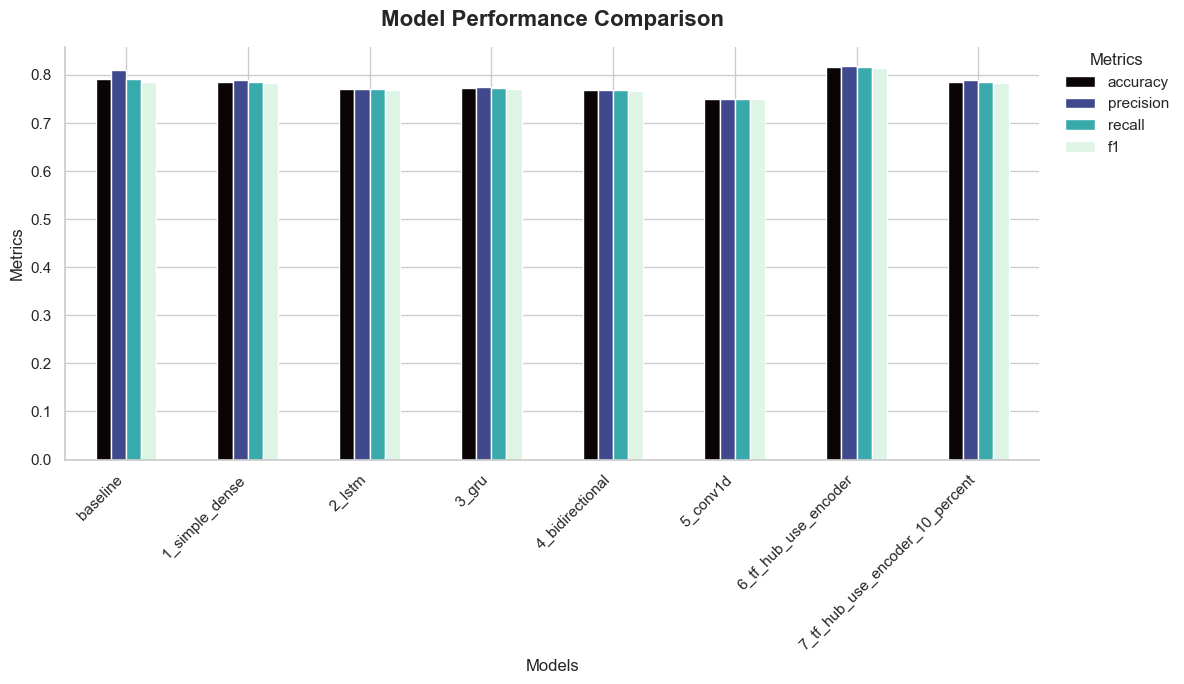

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a clean and modern seaborn style
sns.set_theme(style="whitegrid")

# Create the plot using pandas, but with the 'mako' colormap from seaborn
ax = all_model_results.plot(kind="bar", figsize=(12, 7), cmap="mako")

# Customize title and axes
plt.title("Model Performance Comparison", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Metrics", fontsize=12)

# Rotate x-axis labels to make them easier to read
plt.xticks(rotation=45, ha="right")

# Adjust the legend to sit outside the plot
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Metrics")

# Remove the top and right spines (makes the plot look cleaner)
sns.despine()

# Ensure nothing (like the legend or x-axis labels) gets cut off
plt.tight_layout()

# Show the plot
plt.show()

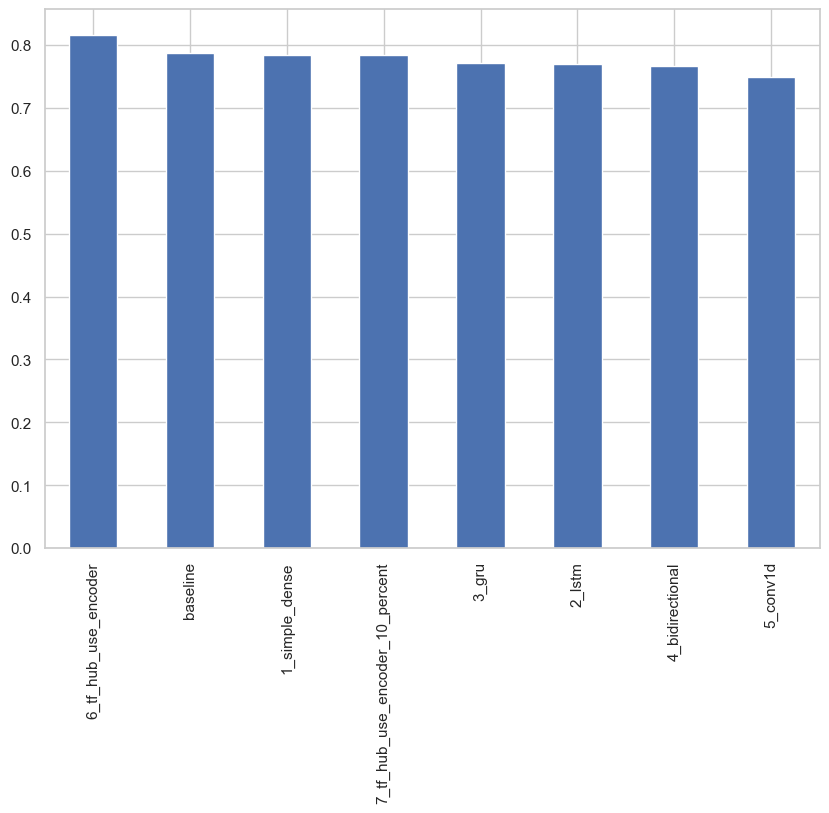

In [108]:
# Sort model results by f1-score
all_model_results.sort_values(by=["f1"], ascending=False)["f1"].plot(kind="bar", figsize=(10,7));


## PLEASE USE http://localhost:6010/ TO OPEN THE PROJECTOR IN A LOCAL MACHINE OF THE MODEL LOGS FOLDER


In [109]:
%load_ext tensorboard

# Testando abrir a pasta de um único modelo
%tensorboard --logdir "C:\Project_1\model_logs" --port 6010

Reusing TensorBoard on port 6010 (pid 11568), started 3 days, 2:12:29 ago. (Use '!kill 11568' to kill it.)

In [110]:
# If didn't work, try this:
!tensorboard --logdir "C:\Project_1\model_logs" --port 6010


E0417 19:23:08.185417 12316 program.py:298] TensorBoard could not bind to port 6010, it was already in use
ERROR: TensorBoard could not bind to port 6010, it was already in use


## Saving and loading a training model

There are two main formats to save a model to in TensorFlow:
- The HDF5 format
- The SavedModel format (this is the default when using TensorFlow)



In [111]:
 # Save TF Hub Sentence Encoder model to HDF5 format
model_6.save("model_6_h5")

INFO:tensorflow:Assets written to: model_6_h5\assets


INFO:tensorflow:Assets written to: model_6_h5\assets


In [112]:
# Load model with custom Hub layer (required HDF5 format)
loaded_model_6 = tf.keras.models.load_model("model_6_h5",
                                            custom_objects={"KerasLayer": hub.KerasLayer})

In [113]:
# How does our model perform?
loaded_model_6.evaluate(val_sentences, val_labels)

24/24 [==============================] - 0s 3ms/step - loss: 0.4272 - accuracy: 0.8163


[0.42716675996780396, 0.8162729740142822]

Now let's save to the `savedmodel` format

In [114]:
# Save TF hub sentence Encoder model to Saved_model format (default)
model_6.save("model_6_SavedModel_format")

INFO:tensorflow:Assets written to: model_6_SavedModel_format\assets


INFO:tensorflow:Assets written to: model_6_SavedModel_format\assets


In [115]:
# Load in amodel from the savemodel format
loaded_model_6_SavedModel_format = tf.keras.models.load_model("model_6_SavedModel_format")

In [116]:
# Evaluate model in SavedModel format
loaded_model_6_SavedModel_format.evaluate(val_sentences, val_labels)

24/24 [==============================] - 0s 3ms/step - loss: 0.4272 - accuracy: 0.8163


[0.42716675996780396, 0.8162729740142822]

## Finding the most wrong examples
• If our best model still isn't perfect, what examples is it getting wrong?
• And of these wrong examples which ones is it getting most wrong (those with prediction probabilities closest to the opposite class)

For example, if a sample should have a label of 0 but our model predicts a probability of 0.999 (really close to 1), and vice versa.

In [ ]:
# import zipfile
# import urllib.request

# # Baixar o arquivo ZIP
# url = "https://storage.googleapis.com/ztm_tf_course/08_model_6_USE_feature_extractor.zip"
# zip_path = "08_model_6_USE_feature_extractor.zip"
# urllib.request.urlretrieve(url, zip_path)

# # # Descompactar o arquivo ZIP
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall()

In [118]:
# Import previously trained model from Google storage
model_6_pretrained = tf.keras.models.load_model("08_model_6_USE_feature_extractor")
model_6_pretrained.evaluate(val_sentences, val_labels)

24/24 [==============================] - 1s 4ms/step - loss: 0.4272 - accuracy: 0.8163


[0.42723122239112854, 0.8162729740142822]

In [ ]:
# Make predi

In [120]:
# Create a dataframe with validation sentences and best performing model predictions
model_6_pretrained_pred_probs = model_6_pretrained.predict(val_sentences)
model_6_pretrained_preds = tf.squeeze(tf.round(model_6_pretrained_pred_probs))
model_6_pretrained_preds[:10] # these should be in label format

24/24 [==============================] - 1s 4ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 1., 1., 1., 1., 1., 0.], dtype=float32)>

In [123]:
# Create Dataframe with validation sentences, validation labels and best performing model predictions labels + probabilities
val_df = pd.DataFrame({"text": val_sentences,
                       "target": val_labels,
                       "pred": model_6_pretrained_preds,
                       "pred_prob": tf.squeeze(model_6_pretrained_pred_probs)})
val_df.head()


,text,target,pred,pred_prob
0,DFR EP016 Monthly Meltdown - On Dnbheaven 2015...,0,0.0,0.159757
1,FedEx no longer to transport bioterror germs i...,0,1.0,0.747162
2,Gunmen kill four in El Salvador bus attack: Su...,1,1.0,0.988749
3,@camilacabello97 Internally and externally scr...,1,0.0,0.196229
4,Radiation emergency #preparedness starts with ...,1,1.0,0.707808


In [124]:
# Find the wrong predictions and sort by prediction probabilities
most_wrong = val_df[val_df["target"]!= val_df["pred"]].sort_values("pred_prob", ascending=False)
most_wrong[:10]

Let’s remind ourselves of the target labels…  
• 0 = not disaster  
• 1 = disaster